#**Dog/Cat using Neural Network**

  Dataset : [kaggle RiceTypeClassification](https://www.kaggle.com/datasets/aleemaparakatta/cats-and-dogs-mini-dataset?utm_)

##importing necessary libraries/data

In [23]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from PIL import Image #load img data into PyTorch
from torchvision import transforms #convert img to tnsor
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device='cuda' if torch.cuda.is_available() else 'cpu'
print('Device : ',device)

Device :  cuda


##Loading the data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.listdir('/content/drive/MyDrive')

['covid-19.csv',
 'Colab Notebooks',
 'Indian_rental_prices.csv',
 'House Price India.csv',
 'Housing_price_prediction_.pkl',
 'Housing_price_model.joblib',
 'Housing_price_prediction_.joblib',
 'diabetes_prediction_dataset.csv',
 'model_classification_.joblib',
 'riceClassification.csv',
 'dog-cat_img_data']

In [5]:
os.listdir('/content/drive/MyDrive/dog-cat_img_data')

['cats_set', 'dogs_set']

##Resizing the Image

In [6]:
data_path='/content/drive/MyDrive/dog-cat_img_data'
cat_path = data_path +'/cats_set'
dog_path= data_path +'/dogs_set'

print('Cats : ', len(os.listdir(cat_path)))
print('Dogs : ', len(os.listdir(dog_path)))
print('\nExample Cat file : ')
print(os.listdir(cat_path)[:5])
print("\nExample dog files:")
print(os.listdir(dog_path)[:5])

Cats :  500
Dogs :  500

Example Cat file : 
['cat.4021.jpg', 'cat.4020.jpg', 'cat.4032.jpg', 'cat.4044.jpg', 'cat.4003.jpg']

Example dog files:
['dog.4005.jpg', 'dog.4027.jpg', 'dog.4028.jpg', 'dog.4042.jpg', 'dog.4011.jpg']


File :  cat.4021.jpg
Size :  (399, 311)
Mode :  RGB


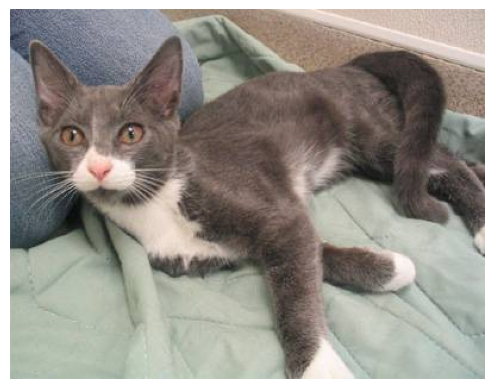

In [7]:
cat_file=os.listdir(cat_path)[0]  #stores the file name of cat img on the folder cats_set with index=0
img_path=os.path.join(cat_path,cat_file) #joins the file name to the cat_path leading to a img path
img=Image.open(img_path) #loads the img file into memory

print('File : ',cat_file)
print('Size : ', img.size)
print('Mode : ',img.mode)

plt.imshow(img) #shows the img on screen with matplotlib.pyplot
plt.axis('off')
plt.show()

In [8]:
#transform=transforms.Compose([transforms.Resize(224*224)]) #Resize image into 224*224

transform=transforms.Resize((224,224))


Origibal size :  (399, 311)
Resized img size :  (224, 224)


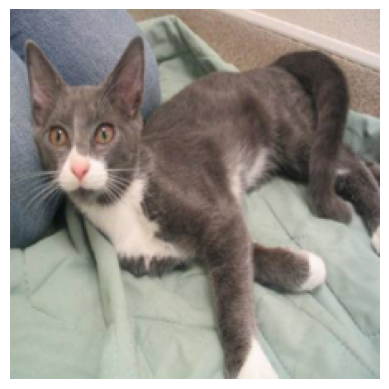

In [9]:
resize_img=transform(img)
print('Origibal size : ',img.size)
print('Resized img size : ',resize_img.size)
plt.imshow(resize_img)
plt.axis('off')
plt.show()

##Resing and converting to tensors and testing on single image

In [10]:
transform=transforms.Compose([
    (transforms.Resize((224,224))),
    (transforms.ToTensor())
])

tensor_img=transform(img)

print(f'''
Typr : {type(tensor_img)}
Shape : {tensor_img.shape}
min pixel val : {tensor_img.min()}
max pixel val : {tensor_img.max()}''')


Typr : <class 'torch.Tensor'>
Shape : torch.Size([3, 224, 224])
min pixel val : 0.027450980618596077
max pixel val : 1.0


##Transforming the dataset through the class

###Adding the data into array :
- x (img_path)
- y (labels)

In [11]:
x=[]
y=[]

#CAT
for file in os.listdir(cat_path):
  x.append(os.path.join(cat_path,file))
  y.append(0)
#DOG
for file in os.listdir(dog_path):
  x.append(os.path.join(dog_path,file))
  y.append(1)

###**CatDogDataset class**

In [12]:
class CatDogDataset(Dataset):
  def __init__(self,x,y,transform):
    super().__init__()
    self.x=x
    self.y=y
    self.transform=transform

  def __len__(self):
    return len(self.x)

  def __getitem__(self,index):  #index exist for both x,y in the array
    img_path=self.x[index]      #returns the location for an image in array x
    label=self.y[index]         #returns the label i.e. 1/0 for the same index in array y
    img=Image.open(img_path).convert('RGB') #loads the image into memory using it's img_path
    img=self.transform(img)     #apply transform to the img i.e. resize & .ToTensor()
    return img,label

In [13]:
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset=CatDogDataset(x,y,transform)

In [14]:
img,label=dataset[0]
print(f'''
      Total images : {len(dataset)}
      Image Shape  : {img.shape}
      Label        : {label}''')


      Total images : 1000
      Image Shape  : torch.Size([3, 224, 224])
      Label        : 0


##train_test_split

In [15]:
#70% train, 15% test, 15% validation

x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=.3,random_state=42,stratify=y) #random_state is a seed point , when split happens it starts from a same point/index
x_val,x_test,y_val,y_test= train_test_split(x_test,y_test,test_size=.5,random_state=42,stratify=y_test) #stratify=y means when data is split it maintains the same ratio of cat and dog as initial i.e. 1:1

In [16]:
train_dataset= CatDogDataset(x_train,y_train,transform)
test_dataset= CatDogDataset(x_test,y_test,transform)
val_dataset= CatDogDataset(x_val,y_val,transform)

##DataLoader

In [19]:
train_loader= DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader= DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader= DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

##Feeding the DataLoader to the Model(CNN)


In [ ]:
ing,label=next(iter(train_loader)) #returns 2 array, one with images and one with lable

In [25]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1=nn.conv2d( #conv2d -> covulation operation on img
        in_channels=3,
        out_channels=16,
        #out_channel creates different filter/property of the img such as edge, texture, vertical pattern, etc.
        kernal_size=3, #this makes a 3X3 filter/matrix throgh which the model looks into the img
        paddinng=1 #adds extra pixels around the border so we dont losses informationt in the edges

    )
    self.pool=nn.MaxPool2d(kernal_size=2)
    '''
    the kernal_size=2 reates a 2X2 view wino=dow which looks into a matrix
    and picks the Max number and goes on thus returning a new matrix
    for example if theres a matrix
    1 2 4 6 7 8
    3 3 5 6 9 0
    1 0 3 4 5 6
    9 2 3 4 7 7
    the nn.MaxPool2d(kernal_size=2) returns
    3 6 9
    9 4 7  the matrix went from (4,6) --> (2,3)
    '''

    self.conv2=nn.conv2d(
        in_channels=16,
        out_channel=32,
        kernal_size=3,
        padding=1
    )

    self.fc1=nn.Linear(
        32*56*56,
        128
    )
    self.fc2=nn.Linear(
        128,
        1
    )

  def forward(self,x):
    x=self.conv1(x)
    x=torch.relu(x)
    x=self.pool(x)

    x=self.conv2(x)
    x=torch.relu(x)
    x=self.pool(x)

    x=torch.flatten(x,start_dim=1)

    '''
    now x is (32,32,56,56) -> 32 img , 32 channels, 56*56 pixels
    now we must CONVERT 'X' INTO A LONG VECTOR i.e. FLATTEN it.
    (32,32,56,56) --> (32,(32*(56*56))) --> (32,100352)
    '''
    x=self.fc1(x)
    x=torch.relu(x)
    x=self.fc2(x)

    return x


In [22]:
model=CNN()

100352